# The Maxwell-Boltzmann distribution

Continuing directly from the microstate count $W=N!/(n_0!\,n_1!\cdots)$: maximizing $W$ subject to
fixed particle number and fixed total energy gives an exponential population law. Following Serway,
*Modern Physics*, Chapter 10, the probability that a particle occupies a state of energy $E_i$ at
absolute temperature $T$ is

$$f_{\rm MB} = A\,e^{-E_i/k_BT}, \tag{10.3}$$

and if the level has degeneracy (statistical weight) $g_i$, the number of particles in it is

$$n_i = g_i\,f_{\rm MB} = g_i A\,e^{-E_i/k_BT}, \tag{10.4}
\qquad N = \sum_i n_i. \tag{10.5}$$

The normalization $A$ is fixed by $N=\sum_i n_i$. Two consequences carry this notebook:

1. **Level populations** fall exponentially with energy. Ratios remove $A$:
   $\dfrac{n_j}{n_i}=\dfrac{g_j}{g_i}\,e^{-(E_j-E_i)/k_BT}$. We reproduce Serway's Example 10.1
   (emission lines from stellar hydrogen).
2. In the continuum, the density of states $g(E)\propto v^2$ turns (10.4) into **Maxwell's speed
   distribution** (10.8), whose moments give the mean, rms, and most-probable speeds.

The notebook is self-contained: only NumPy, SymPy, Pandas, and Matplotlib are required.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The Boltzmann factor and its dimension

The argument $E_i/k_BT$ must be dimensionless: $[k_B]=\mathrm{J/K}$, so $k_BT$ is an energy and the
ratio is a pure number. At room temperature $k_BT\approx 0.0259\ \mathrm{eV}$; at a stellar
$20{,}000\ \mathrm{K}$ it is $\approx 1.72\ \mathrm{eV}$. These two scales decide whether excited
atomic states (electron-volts above the ground state) are populated at all.

In [2]:
kT = U.Quantity(C.K_B, U.ENERGY/U.TEMPERATURE) * U.Quantity(300.0, U.TEMPERATURE)
print("k_B T dimension:", kT.dim, "-> energy:", kT.dim == U.ENERGY)
def kT_eV(T):
    return C.K_B * T / C.E            # thermal energy in electron-volts
for T in (300.0, 20000.0):
    print(f"T = {T:8.0f} K   k_B T = {kT_eV(T):.4f} eV")
assert abs(kT_eV(300) - 0.02585) < 1e-4

k_B T dimension: L^2 M^1 T^-2 -> energy: True
T =      300 K   k_B T = 0.0259 eV
T =    20000 K   k_B T = 1.7235 eV


## Example 10.1 -- Emission lines from stellar hydrogen

Hydrogen levels are $E_n=-13.6/n^2\ \mathrm{eV}$ with degeneracy $g_n=2n^2$. Populations relative to
the ground state are $\dfrac{n_j}{n_1}=\dfrac{g_j}{g_1}\,e^{-(E_j-E_1)/k_BT}$. At $300\ \mathrm{K}$ the
excited states are essentially empty; at $20{,}000\ \mathrm{K}$ they are measurably populated. The
emission-line strength is proportional to the upper-state population (equal transition
probabilities assumed), giving $\dfrac{S(3\to1)}{S(2\to1)}=\dfrac{n_3}{n_2}=0.75$.

In [3]:
levels = {1: (-13.6, 2), 2: (-3.40, 8), 3: (-1.51, 18)}    # n: (E_n [eV], g_n = 2n^2)
def pop_ratio(j, i, T):
    (Ej, gj), (Ei, gi) = levels[j], levels[i]
    return (gj/gi) * np.exp(-(Ej - Ei) / kT_eV(T))

rows = []
for T in (300.0, 20000.0):
    rows.append({"T (K)": T, "n2/n1": pop_ratio(2,1,T), "n3/n1": pop_ratio(3,1,T),
                 "n3/n2 = S(3->1)/S(2->1)": pop_ratio(3,2,T)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
# textbook checks: ground state dominates at 300 K; the emission-strength ratio is 0.75 at 20000 K
assert pop_ratio(2,1,300) < 1e-100                       # 4 * e^{-395} ~ 0
assert abs(pop_ratio(2,1,20000) - 0.0107) < 5e-4         # n2/n1 = 0.0107
assert abs(pop_ratio(3,2,20000) - 0.75) < 0.02           # S(3->1)/S(2->1) = 0.75

  T (K)         n2/n1         n3/n1  n3/n2 = S(3->1)/S(2->1)
  300.0 1.776649e-171 7.098746e-203             3.995581e-32
20000.0  1.075903e-02  8.085309e-03             7.514905e-01


## From populations to Maxwell's speed distribution

For a monatomic ideal gas each particle has $E=\tfrac12 mv^2$. The number of velocity states between
$v$ and $v+dv$ is the volume of a spherical shell in velocity space, $g(E)\,dE\propto 4\pi v^2\,dv$.
Multiplying the density of states by the Boltzmann factor $e^{-mv^2/2k_BT}$ and normalizing to the
number density $N/V$ gives Serway's Eq. (10.8):

$$n(v)\,dv=\frac{4\pi N}{V}\left(\frac{m}{2\pi k_BT}\right)^{3/2}v^2\,e^{-mv^2/2k_BT}\,dv. \tag{10.8}$$

SymPy confirms that the coefficient $A=(m/2\pi k_BT)^{3/2}$ is exactly what makes
$\int_0^\infty n(v)\,dv=N/V$.

In [4]:
m, kB, T, v = sp.symbols('m k_B T v', positive=True)
a = m/(2*kB*T)                                            # so the exponent is -a v^2
shape = v**2 * sp.exp(-a*v**2)
I2 = sp.integrate(shape, (v, 0, sp.oo))                   # normalization integral
print("int_0^inf v^2 e^{-a v^2} dv =", sp.simplify(I2))
# require 4 pi A I2 = 1  ->  A = 1/(4 pi I2); check it equals (m/2 pi kB T)^{3/2}
A = sp.simplify(1/(4*sp.pi*I2))
assert sp.simplify(A - (m/(2*sp.pi*kB*T))**sp.Rational(3,2)) == 0
print("normalization A =", A, " = (m/2 pi kB T)^(3/2)  [verified]")

int_0^inf v^2 e^{-a v^2} dv = sqrt(2)*sqrt(pi)*T**(3/2)*k_B**(3/2)/(2*m**(3/2))
normalization A = sqrt(2)*m**(3/2)/(4*pi**(3/2)*T**(3/2)*k_B**(3/2))  = (m/2 pi kB T)^(3/2)  [verified]


## Characteristic speeds from the moments

Three speeds summarize the distribution, each a different moment integral:
- **most probable** $v_{\rm mp}$: the maximum of $n(v)$, from $\frac{d}{dv}\big(v^2e^{-av^2}\big)=0$;
- **mean** $\bar v=\langle v\rangle$, the first moment;
- **root-mean-square** $v_{\rm rms}=\sqrt{\langle v^2\rangle}$, from the second moment.

SymPy evaluates the Gaussian integrals and returns the textbook closed forms
$v_{\rm mp}=\sqrt{2k_BT/m}$, $\bar v=\sqrt{8k_BT/\pi m}$ (Eq. 10.12), $v_{\rm rms}=\sqrt{3k_BT/m}$.

In [5]:
v_mp = sp.solve(sp.diff(shape, v), v)[0]              # maximum of the distribution
mean_v = sp.simplify(sp.integrate(v*shape, (v,0,sp.oo)) / I2)
v_rms = sp.sqrt(sp.simplify(sp.integrate(v**2*shape, (v,0,sp.oo)) / I2))
print("v_mp  =", v_mp,  " = sqrt(2 kB T/m)")
print("v_bar =", mean_v, " = sqrt(8 kB T/ pi m)")
print("v_rms =", v_rms,  " = sqrt(3 kB T/m)")
assert sp.simplify(v_mp  - sp.sqrt(2*kB*T/m)) == 0
assert sp.simplify(mean_v - sp.sqrt(8*kB*T/(sp.pi*m))) == 0
assert sp.simplify(v_rms  - sp.sqrt(3*kB*T/m)) == 0
# ordering v_mp < v_bar < v_rms, independent of m, kB, T:
print("ratios  v_mp : v_bar : v_rms = 1 : %.3f : %.3f"
      % (float(sp.sqrt(4/sp.pi)), float(sp.sqrt(sp.Rational(3, 2)))))

v_mp  = sqrt(2)*sqrt(T)*sqrt(k_B)/sqrt(m)  = sqrt(2 kB T/m)
v_bar = 2*sqrt(2)*sqrt(T)*sqrt(k_B)/(sqrt(pi)*sqrt(m))  = sqrt(8 kB T/ pi m)
v_rms = sqrt(3)*sqrt(T)*sqrt(k_B)/sqrt(m)  = sqrt(3 kB T/m)
ratios  v_mp : v_bar : v_rms = 1 : 1.128 : 1.225


In [6]:
# numbers for nitrogen (N2) gas at 300 K
m_N2 = 28 * 1.66053906660e-27           # kg
def speeds(T, mass):
    return dict(v_mp=np.sqrt(2*C.K_B*T/mass), v_bar=np.sqrt(8*C.K_B*T/(np.pi*mass)),
                v_rms=np.sqrt(3*C.K_B*T/mass))
s = speeds(300.0, m_N2)
print("N2 at 300 K:  v_mp = %.0f m/s,  v_bar = %.0f m/s,  v_rms = %.0f m/s"
      % (s['v_mp'], s['v_bar'], s['v_rms']))
assert s['v_mp'] < s['v_bar'] < s['v_rms']
assert abs(s['v_rms'] - 517) < 5                          # textbook ~ 517 m/s

N2 at 300 K:  v_mp = 422 m/s,  v_bar = 476 m/s,  v_rms = 517 m/s


## The Gaussian integral formula

Serway quotes $\displaystyle\int_0^\infty z^{2j}e^{-a z^2}\,dz=\frac{1\cdot3\cdot5\cdots(2j-1)}
{2^{\,j+1}a^{\,j}}\sqrt{\frac{\pi}{a}}$, the workhorse behind every moment above. SymPy verifies it for
$j=1,2,3$.

In [7]:
z, aa = sp.symbols('z a', positive=True)
def rhs(j):
    num = sp.prod([2*t-1 for t in range(1, j+1)]) if j >= 1 else 1
    return sp.Rational(num) / (2**(j+1) * aa**j) * sp.sqrt(sp.pi/aa)
for j in (1, 2, 3):
    lhs = sp.integrate(z**(2*j) * sp.exp(-aa*z**2), (z, 0, sp.oo))
    assert sp.simplify(lhs - rhs(j)) == 0
    print(f"j={j}:  int z^{2*j} e^(-a z^2) dz =", sp.simplify(lhs), " [matches the formula]")

j=1:  int z^2 e^(-a z^2) dz = sqrt(pi)/(4*a**(3/2))  [matches the formula]
j=2:  int z^4 e^(-a z^2) dz = 3*sqrt(pi)/(8*a**(5/2))  [matches the formula]
j=3:  int z^6 e^(-a z^2) dz = 15*sqrt(pi)/(16*a**(7/2))  [matches the formula]


## Plots

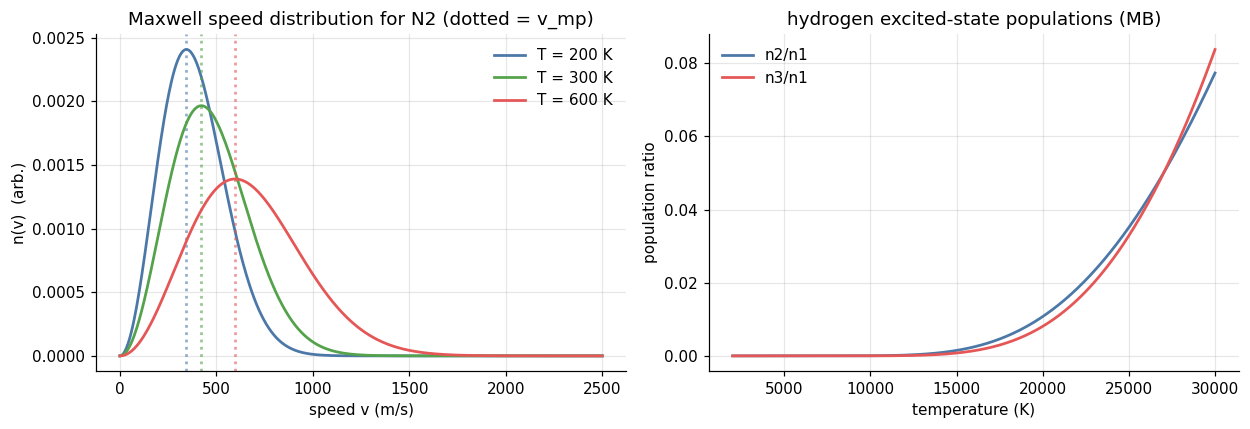

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
# (a) speed distribution at several temperatures (Fig. 10.4)
vv = np.linspace(0, 2500, 600)
for T, c in [(200, "#4C78A8"), (300, "#54A24B"), (600, "#E45756")]:
    A = (m_N2/(2*np.pi*C.K_B*T))**1.5
    nv = 4*np.pi*A * vv**2 * np.exp(-m_N2*vv**2/(2*C.K_B*T))
    ax[0].plot(vv, nv, color=c, label=f"T = {T} K")
    ax[0].axvline(np.sqrt(2*C.K_B*T/m_N2), color=c, ls=":", alpha=0.6)
ax[0].set_xlabel("speed v (m/s)"); ax[0].set_ylabel("n(v)  (arb.)")
ax[0].set_title("Maxwell speed distribution for N2 (dotted = v_mp)"); ax[0].legend()

# (b) hydrogen level populations vs temperature (Example 10.1)
Ts = np.linspace(2000, 30000, 300)
for j, c in [(2, "#4C78A8"), (3, "#E45756")]:
    ax[1].plot(Ts, [pop_ratio(j,1,T) for T in Ts], color=c, label=f"n{j}/n1")
ax[1].set_xlabel("temperature (K)"); ax[1].set_ylabel("population ratio")
ax[1].set_title("hydrogen excited-state populations (MB)"); ax[1].legend()
plt.tight_layout(); plt.show()

## Applied physics and computer engineering

The Boltzmann factor $e^{-E/k_BT}$ is the single most reused exponential in device physics. It sets
the **thermal (Johnson) noise** floor $k_BT$ that an ADC front end fights; the **dark-count** and
leakage rates of a photodiode, which rise as $e^{-E_g/k_BT}$; the carrier populations that the
Fermi-Dirac distribution reduces to in the Boltzmann limit; and the Arrhenius $e^{-E_a/k_BT}$ rate of
any thermally activated process. Numerically, evaluating these distributions is a vectorized
`exp` over an energy or velocity array -- the same array-and-loop pattern as every chapter here, and
the reason a spectrometer's firmware carries a temperature reading alongside every intensity.

Subject-verb-object: temperature populates the levels; the Boltzmann factor weights the energies; the
detector counts the populated states; the software computes the distribution.

## Summary

- The maximized microstate count yields $n_i=g_iA\,e^{-E_i/k_BT}$ (Eqs. 10.3-10.5); ratios cancel
  $A$ and give the exponential population law.
- **Example 10.1** reproduced: at $300\ \mathrm{K}$ hydrogen is entirely in the ground state; at
  $20{,}000\ \mathrm{K}$, $n_2/n_1=0.0107$ and the emission ratio $S(3\to1)/S(2\to1)=0.75$.
- The density of states $g(E)\propto v^2$ turns the Boltzmann factor into Maxwell's speed
  distribution (Eq. 10.8), with $A=(m/2\pi k_BT)^{3/2}$ verified symbolically.
- Its moments give $v_{\rm mp}=\sqrt{2k_BT/m}<\bar v=\sqrt{8k_BT/\pi m}<v_{\rm rms}=\sqrt{3k_BT/m}$
  (517 m/s rms for N2 at 300 K), all from the one Gaussian-integral formula.

This is the statistical bridge from the microstate counting of the previous notebook to the thermal
physics that governs spectra, detectors, and noise.